# Deep Learning Fraud with Magic
  
In this kernel, we build a Deep Learning model for fraud deteciton with magic features introduced in Chris's notebook.

## Reference

Chris's [XGB Fraud with Magic - [0.9600]][1] and [RAPIDS - Feature Engineering - Fraud - [0.96]][2]


[1]: https://www.kaggle.com/cdeotte/xgb-fraud-with-magic-0-9600
[2]: https://www.kaggle.com/cdeotte/rapids-feature-engineering-fraud-0-96/data?

# Load Data
We will load all the data except 219 V columns that were determined redundant by correlation analysis [here][1]

[1]: https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id

In [1]:
FEATURE = True

import warnings
warnings.filterwarnings("ignore")

import datetime
import numpy as np, pandas as pd, os, gc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import callbacks
from tensorflow.keras import backend as K
from tensorflow.keras import utils
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import StandardScaler, LabelEncoder
print("XGBoost version:", xgb.__version__)

print("Tensorflow version " + tf.__version__)
AUTO = tf.data.experimental.AUTOTUNE

# COLUMNS WITH STRINGS
str_type = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain','M1', 'M2', 'M3', 'M4','M5',
            'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
str_type += ['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 
            'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']

# FIRST 53 COLUMNS
cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']

# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN 
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to grous, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

cols += ['V'+str(x) for x in v]
dtypes = {}
for c in cols+['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,34)]+\
    ['id-0'+str(x) for x in range(1,10)]+['id-'+str(x) for x in range(10,34)]:
        dtypes[c] = 'float32'
for c in str_type: dtypes[c] = 'category'

XGBoost version: 1.2.0
Tensorflow version 2.3.0


In [2]:
# Detect hardware, return appropriate distribution strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection. No parameters necessary if TPU_NAME environment variable is set. On Kaggle this is always the case.
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy() # default distribution strategy in Tensorflow. Works on CPU and single GPU.

print("REPLICAS: ", strategy.num_replicas_in_sync)

REPLICAS:  1


In [3]:
MIXED_PRECISION = False
XLA_ACCELERATE = True

if MIXED_PRECISION:
    from tensorflow.keras.mixed_precision import experimental as mixed_precision
    if tpu: policy = tf.keras.mixed_precision.experimental.Policy('mixed_bfloat16')
    else: policy = tf.keras.mixed_precision.experimental.Policy('mixed_float16')
    mixed_precision.set_policy(policy)
    print('Mixed precision enabled')

if XLA_ACCELERATE:
    tf.config.optimizer.set_jit(True)
    print('Accelerated Linear Algebra enabled')

Accelerated Linear Algebra enabled


In [4]:
%%time

if FEATURE:
    
    # LOAD TRAIN
    X_train = pd.read_csv('../input/ieee-with-feature/IEEE_Train.csv', index_col = 'TransactionID')
    # LOAD TEST
    X_test = pd.read_csv('../input/ieee-with-feature/IEEE_Test.csv', index_col = 'TransactionID')
    # LOAD TARGET
    y_train = pd.read_csv('../input/ieee-with-feature/IEEE_Target.csv', index_col = 'TransactionID')
    
else:

    # LOAD TRAIN
    X_train = pd.read_csv('../input/ieee-fraud-detection/train_transaction.csv',index_col='TransactionID', dtype=dtypes, usecols=cols+['isFraud'])
    train_id = pd.read_csv('../input/ieee-fraud-detection/train_identity.csv',index_col='TransactionID', dtype=dtypes)
    X_train = X_train.merge(train_id, how='left', left_index=True, right_index=True)
    # LOAD TEST
    X_test = pd.read_csv('../input/ieee-fraud-detection/test_transaction.csv',index_col='TransactionID', dtype=dtypes, usecols=cols)
    test_id = pd.read_csv('../input/ieee-fraud-detection/test_identity.csv',index_col='TransactionID', dtype=dtypes)
    fix = {o:n for o, n in zip(test_id.columns, train_id.columns)}
    test_id.rename(columns=fix, inplace=True)
    X_test = X_test.merge(test_id, how='left', left_index=True, right_index=True)
    # TARGET
    y_train = X_train['isFraud'].copy()
    del train_id, test_id, X_train['isFraud']; x = gc.collect()
    # PRINT STATUS
    print('Train shape',X_train.shape,'test shape',X_test.shape)

CPU times: user 44 s, sys: 2.86 s, total: 46.9 s
Wall time: 47.2 s


In [5]:
# %%time

# for c in X_train.columns:
    
#     if X_train[c].dtype == 'float64':
    
#         X_train[c] = X_train[c].astype('float32')
#         X_test[c] = X_test[c].astype('float32')
        
#     if X_train[c].dtype == 'int64':
    
#         X_train[c] = X_train[c].astype('int32')
#         X_test[c] = X_test[c].astype('int32')

In [6]:
for c in X_train.columns:
    
    print(X_train[c].dtype)

float64
float64
int64
float64
float64
float64
int64
float64
int64
float64
float64
float64
float64
int64
int64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
int64
int64
int64
int64
int64
int64
int64
int64
int64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
floa

# Normalize D Columns
The D Columns are "time deltas" from some point in the past. We will transform the D Columns into their point in the past. This will stop the D columns from increasing with time. The formula is `D15n = Transaction_Day - D15` and `Transaction_Day = TransactionDT/(24*60*60)`. Afterward we multiple this number by negative one.

In [7]:
if not FEATURE:

    # PLOT ORIGINAL D
    plt.figure(figsize=(15,5))
    plt.scatter(X_train.TransactionDT,X_train.D15)
    plt.title('Original D15')
    plt.xlabel('Time')
    plt.ylabel('D15')
    plt.show()

In [8]:
if not FEATURE:

    # NORMALIZE D COLUMNS
    for i in range(1,16):
        if i in [1,2,3,5,9]: continue
        X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
        X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60) 

In [9]:
if not FEATURE:

    # PLOT TRANSFORMED D
    plt.figure(figsize=(15,5))
    plt.scatter(X_train.TransactionDT,X_train.D15)
    plt.title('Transformed D15')
    plt.xlabel('Time')
    plt.ylabel('D15n')
    plt.show()

In [10]:
%%time

if not FEATURE:

    # LABEL ENCODE AND MEMORY REDUCE
    for i,f in enumerate(X_train.columns):
        # FACTORIZE CATEGORICAL VARIABLES
        if (np.str(X_train[f].dtype)=='category')|(X_train[f].dtype=='object'): 
            df_comb = pd.concat([X_train[f],X_test[f]],axis=0)
            df_comb,_ = df_comb.factorize(sort=True)
            if df_comb.max()>32000: print(f,'needs int32')
            X_train[f] = df_comb[:len(X_train)].astype('int16')
            X_test[f] = df_comb[len(X_train):].astype('int16')
        # SHIFT ALL NUMERICS POSITIVE. SET NAN to -1
        elif f not in ['TransactionAmt','TransactionDT']:
            mn = np.min((X_train[f].min(),X_test[f].min()))
            X_train[f] -= np.float32(mn)
            X_test[f] -= np.float32(mn)
            X_train[f].fillna(-1,inplace=True)
            X_test[f].fillna(-1,inplace=True)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.91 µs


# Encoding Functions
Below are 5 encoding functions. (1) `encode_FE` does frequency encoding where it combines train and test first and then encodes. (2) `encode_LE` is a label encoded for categorical features (3) `encode_AG` makes aggregated features such as aggregated mean and std (4) `encode_CB` combines two columns (5) `encode_AG2` makes aggregated features where it counts how many unique values of one feature is within a group. For more explanation about feature engineering, see the discussion [here][1]

[1]: https://www.kaggle.com/c/ieee-fraud-detection/discussion/108575#latest-641841

In [11]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')
        
# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')
        
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')
                
# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:  
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

# Feature Engineering
We will now engineer features. All of these features where chosen because each increases local validation. The procedure for engineering features is as follows. First you think of an idea and create a new feature. Then you add it to your model and evaluate whether local validation AUC increases or decreases. If AUC increases keep the feature, otherwise discard the feature.

In [12]:
%%time

if not FEATURE:

    # TRANSACTION AMT CENTS
    X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
    X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
    print('cents, ', end='')
    # FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
    encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
    # COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
    encode_CB('card1','addr1')
    encode_CB('card1_addr1','P_emaildomain')
    # FREQUENCY ENOCDE
    encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
    # GROUP AGGREGATE
    encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.15 µs


# Feature Selection - Time Consistency
We added 28 new feature above. We have already removed 219 V Columns from correlation analysis done [here][1]. So we currently have 242 features now. We will now check each of our 242 for "time consistency". We will build 242 models. Each model will be trained on the first month of the training data and will only use one feature. We will then predict the last month of the training data. We want both training AUC and validation AUC to be above `AUC = 0.5`. It turns out that 19 features fail this test so we will remove them. Additionally we will remove 7 D columns that are mostly NAN. More techniques for feature selection are listed [here][2]

[1]: https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
[2]: https://www.kaggle.com/c/ieee-fraud-detection/discussion/111308

In [13]:
if not FEATURE:

    cols = list( X_train.columns )
    cols.remove('TransactionDT')
    for c in ['D6','D7','D8','D9','D12','D13','D14']:
        cols.remove(c)

    # FAILED TIME CONSISTENCY TEST
    for c in ['C3','M5','id_08','id_33']:
        cols.remove(c)
    for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
        cols.remove(c)
    for c in ['id_'+str(x) for x in range(22,28)]:
        cols.remove(c)

In [14]:
if not FEATURE:
    
    print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
    np.array(cols)

In [15]:
if not FEATURE:

    START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
    X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
    X_train['DT_M'] = (X_train['DT_M'].dt.year-2017)*12 + X_train['DT_M'].dt.month 

    X_test['DT_M'] = X_test['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
    X_test['DT_M'] = (X_test['DT_M'].dt.year-2017)*12 + X_test['DT_M'].dt.month 

# The Magic Feature - UID
We will now create and use the MAGIC FEATURES. First we create a UID which will help our model find clients (credit cards). This UID isn't perfect. Many UID values contain 2 or more clients inside. However our model will detect this and by adding more splits with its trees, it will split these UIDs and find the single clients (credit cards).

In [16]:
if not FEATURE:

    X_train['day'] = X_train.TransactionDT / (24*60*60)
    X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)

    X_test['day'] = X_test.TransactionDT / (24*60*60)
    X_test['uid'] = X_test.card1_addr1.astype(str)+'_'+np.floor(X_test.day-X_test.D1).astype(str)

# Group Aggregation Features
For our model to use the new UID, we need to make lots of aggregated group features. We will add 47 new features! The pictures in the introduction to this notebook explain why this works. Note that after aggregation, we remove UID from our model. We don't use UID directly.

In [17]:
%%time

if not FEATURE:

    # FREQUENCY ENCODE UID
    encode_FE(X_train,X_test,['uid'])
    # AGGREGATE 
    encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'],fillna=True,usena=True)
    # AGGREGATE
    encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],X_train,X_test,fillna=True,usena=True)
    # AGGREGATE
    encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'],fillna=True,usena=True)
    # AGGREGATE
    encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'], ['uid'], train_df=X_train, test_df=X_test)
    # AGGREGATE
    encode_AG(['C14'],['uid'],['std'],X_train,X_test,fillna=True,usena=True)
    # AGGREGATE 
    encode_AG2(['C13','V314'], ['uid'], train_df=X_train, test_df=X_test)
    # AGGREATE 
    encode_AG2(['V127','V136','V309','V307','V320'], ['uid'], train_df=X_train, test_df=X_test)
    # NEW FEATURE
    X_train['outsider15'] = (np.abs(X_train.D1-X_train.D15)>3).astype('int8')
    X_test['outsider15'] = (np.abs(X_test.D1-X_test.D15)>3).astype('int8')
    print('outsider15')

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.91 µs


In [18]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
for c in ['DT_M','day','uid']:
    cols.remove(c)

# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [19]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 263 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17',
       'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41',
       'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67',
       'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89',
       'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121',
       'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139',
       'V142', 'V147', 'V156', 'V160', 'V162', 'V165', 'V166', 'V169',
       'V171', 'V173', 'V175', 'V176', 'V178', 'V180', 'V182', 'V185',
       'V187', 'V188', 'V198', 'V203', 'V205', 'V207', 'V209', 'V210',
       '

# Define Deep Learning Model

In [20]:
def create_model(data, catcols, numcols, hidden_units, spatial_dropout_rate, dropout_rate):    
    inp_cat = []
    outputs = []
        
    for c in catcols: 
            
        num_unique_values = int(data[c].nunique())
        embed_dim = int(min(np.ceil((num_unique_values) / 2), 50))
        inp = layers.Input(shape = (1, ))
        out = layers.Embedding(num_unique_values + 1, embed_dim, name = c)(inp)
        out = layers.SpatialDropout1D(spatial_dropout_rate)(out)
        out = layers.Reshape((embed_dim, ))(out)
        inp_cat.append(inp)
        outputs.append(out)
        
    inp_num = layers.Input(shape = (len(numcols),))
    outputs.append(inp_num)

    x = layers.Concatenate()(outputs)
    x = layers.BatchNormalization()(x)
    
    for units in hidden_units:
        
        x = layers.Dense(units, activation = "relu")(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.BatchNormalization()(x)
    
    y = layers.Dense(1, activation = 'sigmoid')(x)

    model = Model(inputs = [inp_cat, inp_num], outputs = y)
    
    return model

In [21]:
catcols = []
numcols = []

for c in X_train[cols].columns:
    if (X_train[c].dtype == 'int64') or (X_train[c].dtype == 'int32'):
        catcols.append(c)
    else:
        numcols.append(c)
        
print(catcols)

['ProductCD', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'card1_addr1', 'card1_addr1_P_emaildomain', 'outsider15']


In [22]:
for c in catcols:

    le = LabelEncoder()
    
    le.fit(np.concatenate([X_train[c], X_test[c]]))
    X_train[c] = le.transform(X_train[c])
    X_test[c] = le.transform(X_test[c])
    
del le
gc.collect()

242

In [23]:
%%time

scaler = StandardScaler()

scaler.fit(pd.concat([X_train[numcols], X_test[numcols]]))
X_train[numcols] = scaler.transform(X_train[numcols])
X_test[numcols] = scaler.transform(X_test[numcols])

del scaler
gc.collect()

CPU times: user 1min 14s, sys: 9.37 s, total: 1min 24s
Wall time: 1min 25s


0

In [24]:
hidden_units = [1024, 512, 256]
spatial_dropout_rate = 0.3
dropout_rate = 0.5

data = pd.concat([X_train[cols], X_test[cols]])

with strategy.scope():

    model = create_model(data, catcols, numcols, hidden_units, spatial_dropout_rate, dropout_rate)
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = [tf.metrics.AUC(name = 'AUC')])

model.summary()

del data
gc.collect()

Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 1)]          0                                            
_______________________________________________________________________________________

0

# Local Validation
We will now perform local validation with the new magic features included. Chris' local validation now achieves AUC = 0.9472 and Konstantin's local validation achieves AUC = 0.9343. Note that without the magic features we achieved AUC = 0.9363 and AUC = 0.9241. We gained AUC 0.01 in both validations therefore our LB should increase from 0.95 to 0.96. Konstantin's LGBM with magic scores Konstantin local validation AUC = 0.9377 [here][1]

[1]: https://www.kaggle.com/kyakovlev/ieee-basic-fe-part-1

In [25]:
# # CHRIS - TRAIN 75% PREDICT 25%
# idxT = X_train.index[:3*len(X_train)//4]
# idxV = X_train.index[3*len(X_train)//4:]

# # KONSTANTIN - TRAIN 4 SKIP 1 PREDICT 1 MONTH
# #idxT = X_train.index[:417559]
# #idxV = X_train.index[-89326:]

In [26]:
import math

class CosineAnnealingScheduler(callbacks.Callback):
    """Cosine annealing scheduler.
    """

    def __init__(self, T_max, eta_max, eta_min = 0, verbose = 0):
        super(CosineAnnealingScheduler, self).__init__()
        self.T_max = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs = None):
        if not hasattr(self.model.optimizer, 'lr'):
            raise ValueError('Optimizer must have a "lr" attribute.')
        lr = self.eta_min + (self.eta_max - self.eta_min) * (1 + math.cos(math.pi * epoch / self.T_max)) / 2
        K.set_value(self.model.optimizer.lr, lr)
        if self.verbose > 0:
            print('\nEpoch %05d: CosineAnnealingScheduler setting learning '
                  'rate to %s.' % (epoch + 1, lr))

    def on_epoch_end(self, epoch, logs = None):
        logs = logs or {}
        logs['lr'] = K.get_value(self.model.optimizer.lr)

In [27]:
# EPOCHS = 100
# ES_P = 10
# LR_MAX = 1e-3
# LR_MIN = 1e-5
# BATCH_SIZE = 4096

# es = callbacks.EarlyStopping(monitor = 'val_AUC', min_delta = 0.0001, patience = ES_P, mode = 'max', 
#                              baseline = None, restore_best_weights = True, verbose = 0)

# cas = CosineAnnealingScheduler(EPOCHS, LR_MAX, LR_MIN)

# ckp = callbacks.ModelCheckpoint('best_model.h5', monitor = 'val_AUC', verbose = 0, 
#                                 save_best_only = True, save_weights_only = True, mode = 'max')

# x_tr = [X_train.loc[idxT, c] for c in catcols] + [X_train.loc[idxT, numcols]]
# y_tr = y_train.loc[idxT]

# x_val = [X_train.loc[idxV, c] for c in catcols] + [X_train.loc[idxV, numcols]]
# y_val = y_train.loc[idxV]

# history = model.fit(x_tr, y_tr, validation_data = (x_val, y_val), callbacks = [ckp, cas, es], 
#                     epochs = EPOCHS, batch_size = BATCH_SIZE, verbose = 1)

# hist = pd.DataFrame(history.history)

In [28]:
# clf = xgb.XGBClassifier( 
#     n_estimators=2000,
#     max_depth=12, 
#     learning_rate=0.02, 
#     subsample=0.8,
#     colsample_bytree=0.4, 
#     missing=-1, 
#     eval_metric='auc',
#     #nthread=4,
#     #tree_method='hist' 
#     tree_method='gpu_hist' 
# )
# h = clf.fit(X_train.loc[idxT,cols], y_train.loc[idxT], 
#     eval_set=[(X_train.loc[idxV,cols],y_train.loc[idxV])],
#     verbose=50, early_stopping_rounds=100)

In [29]:
# feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])

# plt.figure(figsize=(20, 10))
# sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
# plt.title('XGB96 Most Important')
# plt.tight_layout()
# plt.show()

# del clf, h; x=gc.collect()

# Predict test.csv

In [30]:
oof = np.zeros(len(X_train))
preds = np.zeros(len(X_test))

skf = GroupKFold(n_splits=6)
for i, (idxT0, idxV0) in enumerate( skf.split(X_train, y_train, groups=X_train['DT_M']) ):
    month = X_train.iloc[idxV0]['DT_M'].iloc[0]
    print('Fold',i,'withholding month',month)
    print('rows of train =',len(idxT0),'rows of holdout =',len(idxV0))
    
    idxT = X_train.index[idxT0]
    idxV = X_train.index[idxV0]
    
    hidden_units = [1024, 512, 256]
    spatial_dropout_rate = 0.3
    dropout_rate = 0.5
    
    data = pd.concat([X_train[cols], X_test[cols]])

    with strategy.scope():

        clf = create_model(data, catcols, numcols, hidden_units, spatial_dropout_rate, dropout_rate)
        clf.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = [tf.metrics.AUC(name = 'AUC')])

    del data
    x=gc.collect()
    
    EPOCHS = 100
    ES_P = 10
    RLR_P = 5
#     LR_MAX = 1e-3
#     LR_MIN = 1e-5
    BATCH_SIZE = 4096

    es = callbacks.EarlyStopping(monitor = 'val_AUC', min_delta = 0.0001, patience = ES_P, mode = 'max', 
                                 baseline = None, restore_best_weights = True, verbose = 0)
    
    rlr = callbacks.ReduceLROnPlateau(monitor = 'val_AUC', patience = RLR_P, min_lr = 1e-5, verbose = 0, mode = 'max')

#     cas = CosineAnnealingScheduler(EPOCHS, LR_MAX, LR_MIN)

    ckp = callbacks.ModelCheckpoint(f'best_model_{i}.h5', monitor = 'val_AUC', verbose = 0, 
                                    save_best_only = True, save_weights_only = True, mode = 'max')

    x_tr = [X_train.loc[idxT, c] for c in catcols] + [X_train.loc[idxT, numcols]]
    y_tr = y_train.loc[idxT]

    x_val = [X_train.loc[idxV, c] for c in catcols] + [X_train.loc[idxV, numcols]]
    y_val = y_train.loc[idxV]
    
    x_tt = [X_test[c] for c in catcols] + [X_test[numcols]]
    
    h = clf.fit(x_tr, y_tr, validation_data = (x_val, y_val), callbacks = [ckp, rlr, es], 
                epochs = EPOCHS, batch_size = BATCH_SIZE, verbose = 2)

    oof[idxV0] += clf.predict(x_val)[:, 0]
    preds += clf.predict(x_tt)[:, 0] / skf.n_splits
    
    K.clear_session()
    
    del h, clf
    x=gc.collect()
    
print('#'*20)
print ('DL OOF CV=',roc_auc_score(y_train,oof))

Fold 0 withholding month 12
rows of train = 453219 rows of holdout = 137321
Epoch 1/100
111/111 - 18s - loss: 0.3767 - AUC: 0.6864 - val_loss: 0.1546 - val_AUC: 0.7050
Epoch 2/100
111/111 - 19s - loss: 0.1088 - AUC: 0.8689 - val_loss: 0.1122 - val_AUC: 0.7525
Epoch 3/100
111/111 - 15s - loss: 0.0765 - AUC: 0.9374 - val_loss: 0.2007 - val_AUC: 0.7875
Epoch 4/100
111/111 - 15s - loss: 0.0618 - AUC: 0.9632 - val_loss: 0.1163 - val_AUC: 0.8137
Epoch 5/100
111/111 - 15s - loss: 0.0531 - AUC: 0.9745 - val_loss: 0.1534 - val_AUC: 0.8106
Epoch 6/100
111/111 - 15s - loss: 0.0465 - AUC: 0.9802 - val_loss: 0.3871 - val_AUC: 0.8190
Epoch 7/100
111/111 - 15s - loss: 0.0418 - AUC: 0.9836 - val_loss: 0.2425 - val_AUC: 0.7928
Epoch 8/100
111/111 - 15s - loss: 0.0381 - AUC: 0.9864 - val_loss: 0.2616 - val_AUC: 0.7928
Epoch 9/100
111/111 - 16s - loss: 0.0349 - AUC: 0.9878 - val_loss: 0.2408 - val_AUC: 0.7910
Epoch 10/100
111/111 - 15s - loss: 0.0324 - AUC: 0.9896 - val_loss: 0.1798 - val_AUC: 0.7845
Epo

In [31]:
# oof = np.zeros(len(X_train))
# preds = np.zeros(len(X_test))

# skf = GroupKFold(n_splits=6)
# for i, (idxT, idxV) in enumerate( skf.split(X_train, y_train, groups=X_train['DT_M']) ):
#     month = X_train.iloc[idxV]['DT_M'].iloc[0]
#     print('Fold',i,'withholding month',month)
#     print(' rows of train =',len(idxT),'rows of holdout =',len(idxV))
#     clf = xgb.XGBClassifier(
#         n_estimators=5000,
#         max_depth=12,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.4,
#         missing=-1,
#         eval_metric='auc',
#         # USE CPU
#         #nthread=4,
#         #tree_method='hist'
#         # USE GPU
#         tree_method='gpu_hist' 
#     )        
#     h = clf.fit(X_train[cols].iloc[idxT], y_train.iloc[idxT], 
#             eval_set=[(X_train[cols].iloc[idxV],y_train.iloc[idxV])],
#             verbose=100, early_stopping_rounds=200)

#     oof[idxV] += clf.predict_proba(X_train[cols].iloc[idxV])[:,1]
#     preds += clf.predict_proba(X_test[cols])[:,1]/skf.n_splits
#     del h, clf
#     x=gc.collect()
# print('#'*20)
# print ('XGB96 OOF CV=',roc_auc_score(y_train,oof))

In [32]:
# plt.hist(oof,bins=100)
# plt.ylim((0,5000))
# plt.title('XGB OOF')
# plt.show()

# X_train['oof'] = oof
# X_train.reset_index(inplace=True)
# X_train[['TransactionID','oof']].to_csv('oof_xgb_96.csv')
# X_train.set_index('TransactionID',drop=True,inplace=True)

# Kaggle Submission File XGB_96

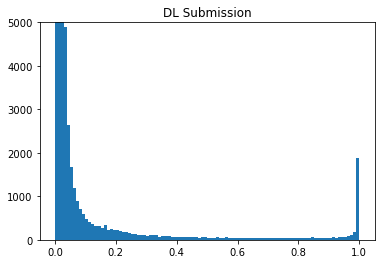

In [33]:
sample_submission = pd.read_csv('../input/ieee-fraud-detection/sample_submission.csv')
sample_submission.isFraud = preds
sample_submission.to_csv('sub_dl.csv',index=False)

plt.hist(sample_submission.isFraud,bins=100)
plt.ylim((0,5000))
plt.title('DL Submission')
plt.show()

In [34]:
# sample_submission = pd.read_csv('../input/ieee-fraud-detection/sample_submission.csv')
# sample_submission.isFraud = preds
# sample_submission.to_csv('sub_xgb_96.csv',index=False)

# plt.hist(sample_submission.isFraud,bins=100)
# plt.ylim((0,5000))
# plt.title('XGB96 Submission')
# plt.show()

# Post Process File XGB_96_PP
Our final submission is an ensemble of XGB, CatBoost, and LGBM. Then we post process the ensemble. We will not load the CatBoost and LGBM here, but we will show you the post process. Konstantin wrote a script [here][1] that finds precise UIDs (more precise than `card1_addr1_D1n`). We believe each to be an individual client (credit card). Analysis shows us that all transactions from a single client (one of Konstantin's UIDs) are either all `isFraud=0` or all `isFraud=1`. In other words, all their predictions are the same. Therefore our post process is to replace all predictions from one client with their average prediction including the `isFraud` values from the train dataset. We have two slightly different versions so we apply them sequentially.

Applying post process on our XGB model increases its Public LB to 0.9618 from LB 0.9602. And increases its Private LB to 0.9341 from LB 0.9324. This is an improvement of LB 0.0016 !!

[1]: https://www.kaggle.com/kyakovlev/ieee-uid-detection-v6

In [35]:
X_test['isFraud'] = sample_submission.isFraud.values
X_train['isFraud'] = y_train.values
comb = pd.concat([X_train[['isFraud']],X_test[['isFraud']]],axis=0)

uids = pd.read_csv('/kaggle/input/ieee-submissions-and-uids/uids_v4_no_multiuid_cleaning..csv',usecols=['TransactionID','uid']).rename({'uid':'uid2'},axis=1)
comb = comb.merge(uids,on='TransactionID',how='left')
mp = comb.groupby('uid2').isFraud.agg(['mean'])
comb.loc[comb.uid2>0,'isFraud'] = comb.loc[comb.uid2>0].uid2.map(mp['mean'])

uids = pd.read_csv('/kaggle/input/ieee-submissions-and-uids/uids_v1_no_multiuid_cleaning.csv',usecols=['TransactionID','uid']).rename({'uid':'uid3'},axis=1)
comb = comb.merge(uids,on='TransactionID',how='left')
mp = comb.groupby('uid3').isFraud.agg(['mean'])
comb.loc[comb.uid3>0,'isFraud'] = comb.loc[comb.uid3>0].uid3.map(mp['mean'])

sample_submission.isFraud = comb.iloc[len(X_train):].isFraud.values
sample_submission.to_csv('sub_dl_PP.csv',index=False)

In [36]:
# X_test['isFraud'] = sample_submission.isFraud.values
# X_train['isFraud'] = y_train.values
# comb = pd.concat([X_train[['isFraud']],X_test[['isFraud']]],axis=0)

# uids = pd.read_csv('/kaggle/input/ieee-submissions-and-uids/uids_v4_no_multiuid_cleaning..csv',usecols=['TransactionID','uid']).rename({'uid':'uid2'},axis=1)
# comb = comb.merge(uids,on='TransactionID',how='left')
# mp = comb.groupby('uid2').isFraud.agg(['mean'])
# comb.loc[comb.uid2>0,'isFraud'] = comb.loc[comb.uid2>0].uid2.map(mp['mean'])

# uids = pd.read_csv('/kaggle/input/ieee-submissions-and-uids/uids_v1_no_multiuid_cleaning.csv',usecols=['TransactionID','uid']).rename({'uid':'uid3'},axis=1)
# comb = comb.merge(uids,on='TransactionID',how='left')
# mp = comb.groupby('uid3').isFraud.agg(['mean'])
# comb.loc[comb.uid3>0,'isFraud'] = comb.loc[comb.uid3>0].uid3.map(mp['mean'])

# sample_submission.isFraud = comb.iloc[len(X_train):].isFraud.values
# sample_submission.to_csv('sub_xgb_96_PP.csv',index=False)